# Phase 3 · Notebook 3 — 03_RFM_Segmentation
Two segmentation lenses, honestly compared:
1. **Rule-based** — qcut quartile scores + explicit business labels (SQL Q40 ka refined pandas version)
2. **Data-driven** — KMeans on scaled RFM, k chosen by **silhouette sweep** (no elbow eyeballing, no cherry-picked k)

### Reporting rules (Phase 0 findings, unchanged)
- **R1** Headline money = `currency='INR'` (USD segment measured & excluded)
- **R2** Reference "today" = `MAX(order_datetime)` in the data
- **R3** NULL-FK rows kept in overall aggregates, drop out of restaurant rollups


## Setup

In [1]:
# ---- boilerplate: paths, DB engine (SQLAlchemy from .env), helper --------
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "python").is_dir() and (ROOT.parent / "python").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "python" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
load_dotenv(ROOT / ".env")

DB_URL = os.getenv("DATABASE_URL")
assert DB_URL, "DATABASE_URL missing - check .env in the repo root"
engine = create_engine(DB_URL)

def q(sql):
    """read_sql via text(): keeps parameters=None so literal '%' in ILIKE is safe."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("ROOT:", ROOT, "| OUT:", OUT, "| DB connected OK", sep="\n")


ROOT:
D:\Projects\bharatinsight
| OUT:
D:\Projects\bharatinsight\python\outputs
| DB connected OK


## RFM per customer (reference date = data ki last date + 1)

In [2]:
rfm = q("""
WITH ref AS (SELECT MAX(order_datetime)::date + 1 AS ref_date FROM orders)
SELECT o.user_id,
       (SELECT ref_date FROM ref) - MAX(o.order_datetime)::date AS recency_days,
       COUNT(*) AS frequency,
       SUM(o.sales_amount) FILTER (WHERE o.currency='INR') AS monetary_inr
FROM orders o WHERE o.user_id IS NOT NULL GROUP BY o.user_id
""")
rfm["monetary_inr"] = rfm["monetary_inr"].fillna(0)
print(rfm.shape); print(rfm.describe().round(1).to_string())

(77929, 4)
       user_id  recency_days  frequency  monetary_inr
count  77929.0       77929.0    77929.0       77929.0
mean   50028.2         415.8        1.9       12659.8
std    28887.8         271.7        1.0       42026.7
min        1.0           1.0        1.0           0.0
25%    24978.0         180.0        1.0         426.0
50%    50008.0         381.0        2.0        1958.0
75%    75120.0         631.0        2.0        8958.0
max    99999.0         997.0        9.0     1514634.0


## Lens 1 — qcut scores + business-rule labels
`rank(method='first')` pehle — isse identical values alag bins me padti hain aur qcut kabhi 'duplicate bin edges' error nahi deta.

In [3]:
def score(s, labels):
    return pd.qcut(s.rank(method="first"), 4, labels=labels).astype(int)

rfm["R"] = score(rfm["recency_days"], [4,3,2,1])   # recent = high score
rfm["F"] = score(rfm["frequency"],   [1,2,3,4])
rfm["M"] = score(rfm["monetary_inr"],[1,2,3,4])
tot = rfm["R"] + rfm["F"] + rfm["M"]
rfm["segment"] = np.select(
    [tot>=11, tot>=9, tot>=7, tot>=5],
    ["Champions","Loyal","Potential Loyalist","At Risk"], default="Lost")
print(rfm["segment"].value_counts().to_string())

segment
Potential Loyalist    19732
Loyal                 18730
At Risk               17886
Lost                  11077
Champions             10504


## Lens 2 — KMeans, k by silhouette sweep (k=2..8)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(np.log1p(rfm[["recency_days","frequency","monetary_inr"]]))
scores = {}
for k in range(2, 9):
    lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    scores[k] = silhouette_score(X, lab, sample_size=min(10000, len(X)), random_state=42)
    print(f"k={k}  silhouette={scores[k]:.4f}")
best_k = max(scores, key=scores.get)
print(f"\nChosen k = {best_k} (highest silhouette = {scores[best_k]:.4f})")
print("NOTE: silhouette < 0.25 would honestly mean 'clusters are weak-overlap' — reported as-is.")

rfm["cluster"] = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit_predict(X)
prof = (rfm.groupby("cluster")
        .agg(customers=("user_id","count"), avg_recency=("recency_days","mean"),
             avg_frequency=("frequency","mean"), avg_monetary=("monetary_inr","mean")).round(1))
print(prof.to_string())

k=2  silhouette=0.3430


k=3  silhouette=0.3320


k=4  silhouette=0.3072


k=5  silhouette=0.3268


k=6  silhouette=0.3366


k=7  silhouette=0.3330


k=8  silhouette=0.3387

Chosen k = 2 (highest silhouette = 0.3430)
NOTE: silhouette < 0.25 would honestly mean 'clusters are weak-overlap' — reported as-is.
         customers  avg_recency  avg_frequency  avg_monetary
cluster                                                     
0            41800        546.0            1.2        3187.2
1            36129        265.1            2.7       23619.3


## Silhouette curve + cluster scatter

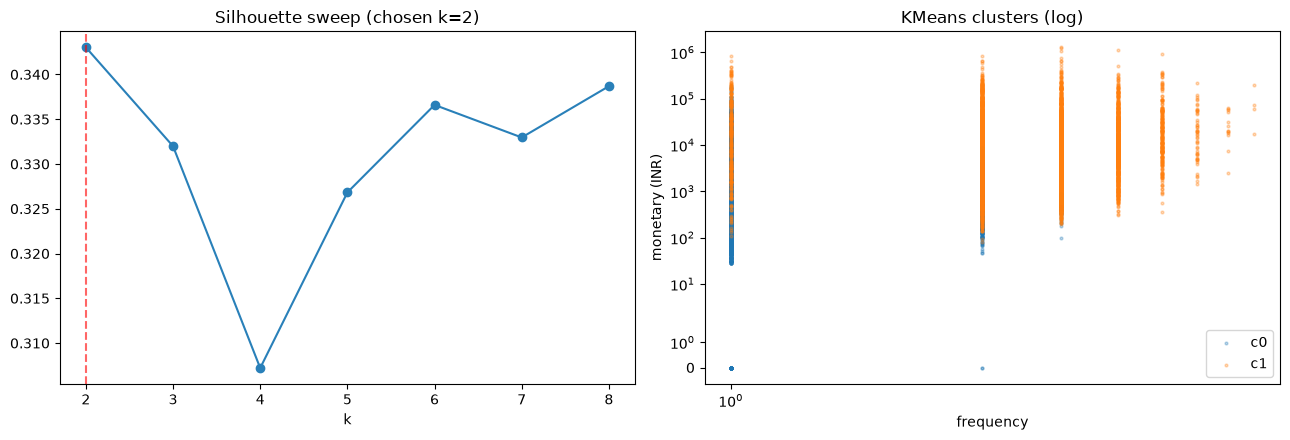

In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
a1.plot(list(scores.keys()), list(scores.values()), "o-", color="#2980b9")
a1.axvline(best_k, color="red", ls="--", alpha=.6)
a1.set_title(f"Silhouette sweep (chosen k={best_k})"); a1.set_xlabel("k")
sub = rfm.sample(min(15000,len(rfm)), random_state=42)
for c,d in sub.groupby("cluster"):
    a2.scatter(d["frequency"], d["monetary_inr"], s=4, alpha=.3, label=f"c{c}")
a2.set_xscale("symlog"); a2.set_yscale("symlog")
a2.set_xlabel("frequency"); a2.set_ylabel("monetary (INR)"); a2.set_title("KMeans clusters (log)"); a2.legend()
fig.tight_layout(); fig.savefig(OUT/"rfm_silhouette.png", dpi=150); plt.show()

## Lens 1 vs Lens 2 — crosstab agreement check

In [6]:
xt = pd.crosstab(rfm["segment"], rfm["cluster"], normalize="index").round(2)
print("Row-wise share of each rule-based segment across KMeans clusters:\n")
print(xt.to_string())

Row-wise share of each rule-based segment across KMeans clusters:

cluster                0     1
segment                       
At Risk             0.99  0.01
Champions           0.00  1.00
Lost                1.00  0.00
Loyal               0.03  0.97
Potential Loyalist  0.63  0.37


## Discussion (market-down ko apne words me poora karo)
- Rule-based segments deterministic aur **explainable** hain (interviewer ko 1 line me samjha sakte ho)
- KMeans data ke natural geometry ko pakadta hai, lekin cluster ko **naam tumhe** dene padte hain
- Crosstab me kis cluster me 'Champions' concentrated hain? wahi tumhara data-driven 'Champions' hai
- Agreement zyada = dono lenses same story bol rahi hain = segmentation robust ✅